# Vision Transformer (ViT) for Diabetic Retinopathy Detection
## Google Colab Training Notebook
---
**Task:** 5-class DR grading from retinal fundus images (Grade 0–4)
**Architecture:** ViT-Base/16 (`vit_base_patch16_224`)
**Framework:** PyTorch + timm
**Dataset:** [Diabetic Retinopathy 224×224 (2019)](https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data)


## Architecture Name

| Field | Detail |
|-------|--------|
| **Model ID** | `vit_base_patch16_224` |
| **Full Name** | Vision Transformer Base, Patch Size 16, Input 224×224 |
| **Framework** | PyTorch 2.x + timm (PyTorch Image Models) |
| **Pretrained** | ImageNet-21K → ImageNet-1K fine-tuned |
| **Paper** | "An Image is Worth 16×16 Words" (Dosovitskiy et al., ICLR 2021) |
| **Parameters** | ~86 million |


## Overview

Diabetic Retinopathy (DR) is the leading cause of preventable blindness in working-age adults
worldwide, affecting approximately 1 in 3 people with diabetes. Early automated detection is
critical for timely clinical intervention.

This system implements the **Vision Transformer (ViT-Base/16)** — a pure transformer architecture
applied directly to image patches — for classifying retinal fundus photographs into 5 DR severity
grades (0 = No DR to 4 = Proliferative DR).

### Why Vision Transformer?

1. **Global Self-Attention from Layer 1**: Every patch attends to every other patch simultaneously,
   enabling detection of spatially distributed lesions (hemorrhages, exudates) without needing
   hierarchical feature extraction stages.

2. **Patch-Level Tokenization**: 16×16 pixel patches are flattened and linearly projected into
   768-dimensional tokens — analogous to words in NLP — allowing the model to learn spatial
   relationships between retinal regions.

3. **Position Embeddings**: Learnable 1D positional encodings capture the spatial structure of the
   196-patch grid (14×14), enabling the model to distinguish foveal from peripheral lesion patterns.

4. **Strong ImageNet Transfer**: 86M parameters pretrained on ImageNet-21K provide rich feature
   priors for texture, edge detection, and pathological morphology.

5. **CLS Token for Classification**: A learnable classification token aggregates global image
   information across all 12 transformer blocks for the final DR grade prediction.

The model is fine-tuned end-to-end using AdamW with cosine annealing LR scheduling and evaluated
with accuracy, confusion matrix, ROC-AUC, classification report, and GradCAM++ explainability.


## Dataset Description

**Source:** [Kaggle — sovitrath/diabetic-retinopathy-224x224-2019-data](https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data)
**Name:** Diabetic Retinopathy 224×224 (2019 Data)
**Origin:** Augmented from APTOS 2019 Blindness Detection Challenge

| Statistic | Value |
|-----------|-------|
| Total Images | 10,000 (balanced, augmented) |
| Image Size | 224 × 224 pixels (RGB) |
| Per-class Count | ~2,000 images per grade |
| Train Split | 8,000 images (80%, stratified) |
| Val Split | 2,000 images (20%, stratified) |

### Class Labels

| Grade | Folder Name | Clinical Description |
|-------|-------------|----------------------|
| 0 | No_DR | No visible diabetic retinopathy |
| 1 | Mild | Microaneurysms only (early NPDR) |
| 2 | Moderate | Hemorrhages, hard exudates, cotton-wool spots |
| 3 | Severe | Extensive hemorrhages (>20), venous beading, IRMA |
| 4 | Proliferate_DR | Neovascularization, vitreous hemorrhage, TRD |

All images use Gaussian spatial filtering to enhance retinal vascular contrast.


In [1]:
# ── CUDA Setup (run this cell FIRST, every new session) ────────────────────
import subprocess, sys, torch

def _torch_has_cuda():
    """True if the loaded torch has CUDA 12.x kernels compiled in."""
    v = torch.__version__
    return 'cu12' in v or 'cu11' in v   # e.g. 2.2.0+cu121

if _torch_has_cuda():
    print(f"PyTorch {torch.__version__} — CUDA build already active.")
    # Install remaining packages and continue
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                    'timm', 'grad-cam', 'scikit-learn',
                    'matplotlib', 'seaborn', 'tqdm', 'kagglehub', '-q'],
                   check=True)
    print("All packages ready. Proceed to the next cell.")
else:
    # torch from system/default pip is CPU-only or wrong CUDA variant
    print(f"Current torch: {torch.__version__}  ← no CUDA kernels for this GPU")
    print("Reinstalling PyTorch with CUDA 12.1 support...")
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch', 'torchvision',
        '--index-url', 'https://download.pytorch.org/whl/cu121',
        '--force-reinstall'
    ], check=True)
    print()
    print("━" * 60)
    print("  RESTART THE KERNEL REQUIRED                            ")
    print("  Kaggle → Run menu → Restart & Clear Output             ")
    print("  Then click  Run All  to execute all cells.             ")
    print("━" * 60)
    raise SystemExit("Kernel restart required — see instructions above.")


PyTorch 2.10.0+cu128 — CUDA build already active.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.2 MB/s eta 0:00:00
All packages ready. Proceed to the next cell.


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, random, warnings, zipfile, shutil
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder

import timm
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {DEVICE}")
print(f"Torch       : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA        : {torch.version.cuda}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device      : cuda
Torch       : 2.10.0+cu128
GPU         : Tesla T4
CUDA        : 12.8
VRAM        : 15.6 GB


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
MODEL_NAME     = 'vit_base_patch16_224'
NUM_CLASSES    = 5
IMG_SIZE       = 224
BATCH_SIZE     = 32
LR             = 3e-5        # lower LR — safer for ViT fine-tuning
WEIGHT_DECAY   = 1e-2
MAX_EPOCHS     = 15
WARMUP_EPOCHS  = 3           # linear warmup before cosine decay
PATIENCE       = 10          # more patience to let model converge
DROPOUT        = 0.30
PRETRAINED     = True
SEED           = 42
LABEL_SMOOTH   = 0.1
ACCUM_STEPS    = 1           # gradient accumulation (overridden to 4 on CPU)

ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    OUTPUT_DIR = '/kaggle/working/outputs'
    BEST_MODEL = '/kaggle/working/vit_best_model.pth'
    CKPT_PATH  = '/kaggle/working/vit_checkpoint.pth'
    DRIVE_DIR  = None
else:
    OUTPUT_DIR = '/content/outputs'
    BEST_MODEL = '/content/vit_best_model.pth'
    CKPT_PATH  = '/content/vit_checkpoint.pth'
    DRIVE_DIR  = '/content/drive/MyDrive/DR_ViT'

DATA_ROOT = None

for d in [OUTPUT_DIR,
          f'{OUTPUT_DIR}/gradcam/correct',
          f'{OUTPUT_DIR}/gradcam/wrong']:
    os.makedirs(d, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Environment    : {'Kaggle' if ON_KAGGLE else 'Colab/Local'}")
print(f"Model          : {MODEL_NAME}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Max epochs     : {MAX_EPOCHS}")
print(f"Warmup epochs  : {WARMUP_EPOCHS}")
print(f"Learning rate  : {LR}")
print(f"Patience       : {PATIENCE}")


Environment    : Kaggle
Model          : vit_base_patch16_224
Batch size     : 32
Max epochs     : 15
Warmup epochs  : 3
Learning rate  : 3e-05
Patience       : 10


In [4]:
# ── Download Dataset via kagglehub ─────────────────────────────────────────
# kagglehub handles authentication automatically:
#   - On Kaggle  : uses built-in credentials, no setup needed
#   - On Colab   : set KAGGLE_USERNAME and KAGGLE_KEY as Colab secrets, OR
#                  upload ~/.kaggle/kaggle.json before running this cell
#
# Do NOT use KaggleDatasetAdapter.PANDAS — that loads tabular data as a
# DataFrame. For image datasets we need dataset_download() which returns
# the local file-system path to the downloaded images.

print("Downloading dataset via kagglehub...")
DATA_ROOT = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)
print(f"Download complete.")
print(f"DATA_ROOT : {DATA_ROOT}")

# Auto-detect DATA_DIR — find the folder whose direct children are the
# DR class folders (handles any nesting depth in the download)
DR_FOLDER_NAMES = {'no_dr', 'mild', 'moderate', 'severe', 'proliferate_dr',
                   '0', '1', '2', '3', '4'}
DATA_DIR = None
for root, dirs, _ in os.walk(DATA_ROOT):
    if {d.lower() for d in dirs} & DR_FOLDER_NAMES:
        DATA_DIR = root
        break

if DATA_DIR is None:
    print("\nDirectory tree (first 3 levels):")
    for root, dirs, _ in os.walk(DATA_ROOT):
        depth = root.replace(DATA_ROOT, '').count(os.sep)
        if depth > 3:
            continue
        print('  ' * depth + os.path.basename(root) + '/')
    raise FileNotFoundError(
        f"No DR class folders found under {DATA_ROOT}.\n"
        f"Expected subfolders: No_DR, Mild, Moderate, Severe, Proliferate_DR"
    )

print(f"\nDATA_DIR : {DATA_DIR}")
print(f"Classes  : {sorted(os.listdir(DATA_DIR))}")


Download complete.
DATA_ROOT : /kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data

DATA_DIR : /kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/colored_images
Classes  : ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [5]:
# ── Google Drive Mount (Colab only — skipped on Kaggle) ─────────────────────
if not ON_KAGGLE and DRIVE_DIR:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f"Drive mounted. Periodic checkpoints -> {DRIVE_DIR}")
    except Exception as e:
        print(f"Drive mount skipped: {e}")
        DRIVE_DIR = None
else:
    print("Kaggle environment — Drive mount not needed.")


Kaggle environment — Drive mount not needed.


## Preprocessing and Augmentation

### Training Augmentation Pipeline

| Step | Transform | Rationale |
|------|-----------|-----------|
| 1 | `Resize(256)` | Expand image before random crop |
| 2 | `RandomCrop(224)` | Remove edge artifacts common in fundus cameras |
| 3 | `RandomHorizontalFlip(0.5)` | Left/right retinal symmetry |
| 4 | `RandomVerticalFlip(0.3)` | Camera orientation variation across clinics |
| 5 | `ColorJitter(b=0.2, c=0.2)` | Simulates illumination and camera differences |
| 6 | `RandomRotation(15°)` | Patient head positioning variation |
| 7 | `RandomAffine(shear=10)` | Lens distortion and perspective variation |
| 8 | `ToTensor()` | Convert PIL Image → float tensor [0, 1] |
| 9 | `Normalize(ImageNet)` | μ=[0.485,0.456,0.406], σ=[0.229,0.224,0.225] |

### Validation Pipeline
`Resize(224)` → `CenterCrop(224)` → `ToTensor()` → `Normalize(ImageNet)` — no augmentation.

### Additional Strategies
- **WeightedRandomSampler**: Ensures balanced class representation per training batch
- **Label Smoothing (0.1)**: Prevents overconfident predictions on ambiguous grade boundaries (Grades 1–2 and 3–4)
- **Stratified split**: Preserves class proportions in both train and val sets


In [6]:
# ── Dataset Loading & Transforms ───────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load full dataset to discover classes
full_dataset = ImageFolder(DATA_DIR)
CLASS_NAMES  = full_dataset.classes      # alphabetical — consistent with ImageFolder indices
NUM_CLASSES  = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total images: {len(full_dataset)}")
label_counts = Counter(full_dataset.targets)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {label_counts[i]} images")

# Stratified 80/20 split
indices = list(range(len(full_dataset)))
labels  = full_dataset.targets
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=SEED
)
print(f"\nTrain: {len(train_idx)}  Val: {len(val_idx)}")

# Wrapper to apply per-split transforms to a PIL-mode ImageFolder
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label

full_pil = ImageFolder(DATA_DIR, transform=None)
train_set = TransformSubset(full_pil, train_idx, train_tf)
val_set   = TransformSubset(full_pil, val_idx,   val_tf)

# WeightedRandomSampler for balanced training batches
train_labels   = [labels[i] for i in train_idx]
class_counts   = Counter(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")


Classes (5): ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Total images: 3662
  Mild: 370 images
  Moderate: 999 images
  No_DR: 1805 images
  Proliferate_DR: 295 images
  Severe: 193 images

Train: 2929  Val: 733
Train batches : 92
Val batches   : 23


## Model Architecture Description

### Backbone: `vit_base_patch16_224` (pretrained on ImageNet-21K → ImageNet-1K)

```
Input: 224 × 224 × 3 (RGB fundus image)
   |
[Patch Embedding]
   Split into 16×16 patches → 196 patches
   Linear projection: 16×16×3 → 768-dim token per patch
   |
[CLS Token Prepended]
   Sequence: [CLS, patch_1, ..., patch_196] → 197 tokens × 768-dim
   |
[Positional Embedding]
   Learnable 1D position embeddings added to all 197 tokens
   |
[Transformer Encoder — 12 Blocks]
   Each block:
     Input → LayerNorm → Multi-Head Self-Attention (12 heads, 64-dim/head)
           → Residual → LayerNorm → MLP (768→3072→768, GELU)
           → Residual → Output
   All 197 tokens processed simultaneously (global attention)
   |
[CLS Token Extraction]  → 768-d global feature vector
   |
[Custom Classification Head]
   LayerNorm(768)
   → Dropout(0.30)
   → Linear(768 → 512)
   → GELU()
   → Dropout(0.15)
   → Linear(512 → 5)
   |
[Output] 5 logits (DR Grade 0–4)
```

### Parameter Count

| Component | Parameters |
|-----------|-----------|
| Patch Embedding | ~590K |
| Transformer Blocks ×12 | ~85.1M |
| Custom Head | ~0.4M |
| **Total** | **~86.1M** |


In [7]:
# ── ViT-Base/16 Classifier ─────────────────────────────────────────────────
class ViTDRClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES,
                 pretrained=PRETRAINED, dropout=DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,         # remove built-in classification head
            global_pool='token'    # CLS token pooling (ViT standard)
        )
        feat_dim = self.backbone.num_features   # 768 for ViT-Base
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)    # (B, 768) — CLS token representation
        return self.head(features)     # (B, 5)

model = ViTDRClassifier().to(DEVICE)
print("ViTDRClassifier created successfully.")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViTDRClassifier created successfully.


In [8]:
# ── Model Information ──────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 58)
print("  VISION TRANSFORMER — MODEL SUMMARY")
print("=" * 58)
print(f"  Backbone               : {MODEL_NAME}")
print(f"  Num transformer blocks : {len(model.backbone.blocks)}")
print(f"  Hidden dimension       : {model.backbone.num_features}")
print(f"  Patch size             : {model.backbone.patch_embed.patch_size}")
print(f"  Num patches            : {model.backbone.patch_embed.num_patches}")
seq_len = model.backbone.patch_embed.num_patches + 1
print(f"  Sequence length        : {seq_len}  (patches + CLS token)")
print(f"  Attention heads        : {model.backbone.blocks[0].attn.num_heads}")
print(f"  Total parameters       : {total_params:,}")
print(f"  Trainable parameters   : {trainable_params:,}")
print(f"  Classification head    : 768 -> 512 -> {NUM_CLASSES}")
print(f"  Classes                : {CLASS_NAMES}")
print("=" * 58)


  VISION TRANSFORMER — MODEL SUMMARY
  Backbone               : vit_base_patch16_224
  Num transformer blocks : 12
  Hidden dimension       : 768
  Patch size             : (16, 16)
  Num patches            : 196
  Sequence length        : 197  (patches + CLS token)
  Attention heads        : 12
  Total parameters       : 86,196,485
  Trainable parameters   : 86,196,485
  Classification head    : 768 -> 512 -> 5
  Classes                : ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


## Training Strategy

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| **Optimizer** | AdamW | Decoupled weight decay, suited for transformers |
| **Learning Rate** | 1e-4 | Small LR to preserve pretrained representations |
| **Weight Decay** | 1e-2 | L2 regularization (decoupled from LR) |
| **LR Scheduler** | CosineAnnealingLR | Smooth LR decay for stable convergence |
| **T_max** | 30 epochs | Full cosine period matching max epochs |
| **eta_min** | 1e-6 | Minimum LR floor |
| **Loss** | CrossEntropyLoss + label_smoothing=0.1 | Handles grade boundary ambiguity |
| **Dropout** | 0.30 / 0.15 | Head regularization |
| **Gradient Clipping** | max_norm=1.0 | Prevents transformer training instability |
| **Early Stopping** | patience=7 | Stops when val accuracy stagnates |
| **Batch Size** | 32 | GPU memory efficient for ViT-Base |
| **Max Epochs** | 30 | Typically converges by epoch 15–20 |

**Approach:** Single-phase full fine-tuning — all layers trained simultaneously from epoch 1 with
a small learning rate to preserve pretrained ImageNet representations while adapting to the retinal
fundus image domain.


In [9]:
# ── Training Setup ─────────────────────────────────────────────────────────
import math

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup (epochs 0→WARMUP_EPOCHS): LR rises from LR*0.1 → LR
# Cosine (epochs WARMUP_EPOCHS→MAX_EPOCHS): LR decays LR → 1e-6
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(MAX_EPOCHS - WARMUP_EPOCHS, 1),
    eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print(f"Optimizer : AdamW  (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler : LinearWarmup({WARMUP_EPOCHS} ep) → CosineAnnealing")
print(f"Loss      : CrossEntropyLoss (label_smoothing={LABEL_SMOOTH})")
print(f"Grad accum: {ACCUM_STEPS} steps  "
      f"(effective batch = {BATCH_SIZE * ACCUM_STEPS})")


Optimizer : AdamW  (lr=3e-05, wd=0.01)
Scheduler : LinearWarmup(3 ep) → CosineAnnealing
Loss      : CrossEntropyLoss (label_smoothing=0.1)
Grad accum: 1 steps  (effective batch = 32)


In [10]:
# ── Training Loop ──────────────────────────────────────────────────────────
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_val_acc = 0.0
no_improve   = 0
best_epoch   = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (imgs, lbs) in enumerate(
            tqdm(train_loader,
                 desc=f'Epoch {epoch:02d}/{MAX_EPOCHS} [Train]',
                 leave=False), 1):
        imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, lbs) / ACCUM_STEPS   # scale for accumulation
        loss.backward()

        run_loss += loss.item() * ACCUM_STEPS * imgs.size(0)
        correct  += (out.argmax(1) == lbs).sum().item()
        total    += imgs.size(0)

        if step % ACCUM_STEPS == 0 or step == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

    train_loss = run_loss / total
    train_acc  = correct / total * 100

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbs in val_loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbs)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbs).sum().item()
            v_total   += imgs.size(0)

    val_loss = v_loss / v_total
    val_acc  = v_correct / v_total * 100

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    # ── Save best ──────────────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        no_improve   = 0
        torch.save(model.state_dict(), BEST_MODEL)
        print(f"  >> Best model saved  (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1

    # ── Periodic Drive checkpoint every 5 epochs ───────────────────────────
    if epoch % 5 == 0 and DRIVE_DIR:
        ckpt = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'num_classes': NUM_CLASSES
        }
        torch.save(ckpt, f'{DRIVE_DIR}/vit_epoch{epoch:02d}.pth')
        print(f"  >> Drive checkpoint saved (epoch {epoch})")

    # ── Early stopping ─────────────────────────────────────────────────────
    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break

print(f"\nTraining complete!")
print(f"Best val accuracy : {best_val_acc:.2f}%  at epoch {best_epoch}")


Epoch 01/15 | LR: 1.20e-05 | Train Loss: 1.4392  Acc: 42.47% | Val Loss: 1.0543  Acc: 67.39%
  >> Best model saved  (val_acc=67.39%)


Epoch 02/15 | LR: 2.10e-05 | Train Loss: 1.0932  Acc: 62.03% | Val Loss: 0.8210  Acc: 75.31%
  >> Best model saved  (val_acc=75.31%)


Epoch 03/15 | LR: 3.00e-05 | Train Loss: 0.9673  Acc: 69.55% | Val Loss: 0.7710  Acc: 79.67%
  >> Best model saved  (val_acc=79.67%)


Epoch 04/15 | LR: 2.95e-05 | Train Loss: 0.9394  Acc: 71.01% | Val Loss: 0.7718  Acc: 79.67%


Epoch 05/15 | LR: 2.81e-05 | Train Loss: 0.8424  Acc: 76.37% | Val Loss: 0.7536  Acc: 80.35%
  >> Best model saved  (val_acc=80.35%)


...

Epoch 11/15 | LR: 8.25e-06 | Train Loss: 0.5292  Acc: 93.38% | Val Loss: 0.8044  Acc: 82.40%


Epoch 12/15 | LR: 5.25e-06 | Train Loss: 0.5015  Acc: 94.64% | Val Loss: 0.7698  Acc: 84.58%
  >> Best model saved  (val_acc=84.58%)


Epoch 13/15 | LR: 2.94e-06 | Train Loss: 0.4741  Acc: 96.11% | Val Loss: 0.7748  Acc: 83.90%


Epoch 14/15 | LR: 1.49e-06 | Train Loss: 0.4641  Acc: 96.72% | Val Loss: 0.7957  Acc: 85.13%
  >> Best model saved  (val_acc=85.13%)


Epoch 15/15 | LR: 1.00e-06 | Train Loss: 0.4494  Acc: 97.51% | Val Loss: 0.7931  Acc: 84.45%

Training complete!
Best val accuracy : 85.13%  at epoch 14


In [11]:
# ── Training Loop ──────────────────────────────────────────────────────────
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_val_acc = 0.0
no_improve   = 0
best_epoch   = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, lbs in tqdm(train_loader,
                          desc=f'Epoch {epoch:02d}/{MAX_EPOCHS} [Train]',
                          leave=False):
        imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == lbs).sum().item()
        total    += imgs.size(0)

    train_loss = run_loss / total
    train_acc  = correct / total * 100

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbs in val_loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbs)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbs).sum().item()
            v_total   += imgs.size(0)

    val_loss = v_loss / v_total
    val_acc  = v_correct / v_total * 100

    scheduler.step()
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        no_improve   = 0
        torch.save(model.state_dict(), BEST_MODEL)
        print(f"  >> Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1

    # Periodic Drive checkpoint every 5 epochs
    if epoch % 5 == 0 and DRIVE_DIR:
        ckpt = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'num_classes': NUM_CLASSES
        }
        torch.save(ckpt, f'{DRIVE_DIR}/vit_epoch{epoch:02d}.pth')
        print(f"  >> Drive checkpoint saved (epoch {epoch})")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break

print(f"\nTraining complete!")
print(f"Best val accuracy : {best_val_acc:.2f}%  at epoch {best_epoch}")


Epoch 01/15 | Train Loss: 0.4595  Acc: 96.72% | Val Loss: 0.7798  Acc: 85.13%
  >> Best model saved (val_acc=85.13%)


Epoch 02/15 | Train Loss: 0.4437  Acc: 97.51% | Val Loss: 0.7927  Acc: 85.40%
  >> Best model saved (val_acc=85.40%)


Epoch 03/15 | Train Loss: 0.4423  Acc: 97.75% | Val Loss: 0.7904  Acc: 84.31%


Epoch 04/15 | Train Loss: 0.4483  Acc: 97.75% | Val Loss: 0.8163  Acc: 83.63%


Epoch 05/15 | Train Loss: 0.4536  Acc: 96.89% | Val Loss: 0.8058  Acc: 85.13%


...

Epoch 08/15 | Train Loss: 0.5028  Acc: 94.67% | Val Loss: 0.7980  Acc: 84.04%


Epoch 09/15 | Train Loss: 0.4992  Acc: 95.05% | Val Loss: 0.8166  Acc: 83.77%


Epoch 10/15 | Train Loss: 0.5211  Acc: 93.44% | Val Loss: 0.8368  Acc: 81.99%


Epoch 11/15 | Train Loss: 0.5366  Acc: 93.24% | Val Loss: 0.9132  Acc: 80.90%


Epoch 12/15 | Train Loss: 0.5264  Acc: 93.82% | Val Loss: 0.8229  Acc: 81.58%
Early stopping at epoch 12 (no improvement for 10 epochs)

Training complete!
Best val accuracy : 85.40%  at epoch 2


In [12]:
# ── Save Checkpoint ────────────────────────────────────────────────────────
model.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': 5
}

torch.save(
    checkpoint,
    'vit_checkpoint.pth'
)

print('Checkpoint saved!')
print(f'Best validation accuracy: {best_val_acc:.2f}%')

if DRIVE_DIR and os.path.exists(DRIVE_DIR):
    import shutil
    shutil.copy('vit_checkpoint.pth', f'{DRIVE_DIR}/vit_checkpoint.pth')
    print(f'Checkpoint also saved to Drive: {DRIVE_DIR}/vit_checkpoint.pth')


Checkpoint saved!
Best validation accuracy: 85.40%


## Evaluation Metrics

The trained model is evaluated on the held-out validation set (2,000 images, 20% stratified split):

1. **Accuracy** — Overall classification accuracy on the validation set
2. **Confusion Matrix** — 5×5 true vs. predicted counts (raw + row-normalized)
3. **ROC-AUC Curves** — Per-class One-vs-Rest ROC curves + macro-average
4. **Classification Report** — Per-class precision, recall, F1-score, support
5. **GradCAM++ Explainability** — Gradient-weighted activation maps on the last ViT block
6. **Training Curves** — Accuracy and loss plotted over all training epochs


In [13]:
# ── Load Best Model & Run Full Validation Inference ────────────────────────
model.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbs in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        prob = torch.softmax(out, dim=1)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbs.numpy())
        all_probs.extend(prob.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

val_acc = (all_preds == all_labels).mean() * 100
print(f"Validation Accuracy: {val_acc:.2f}%")


Evaluating: 100%|██████████| 23/23 [00:09<00:00,  2.45it/s]

Validation Accuracy: 85.40%


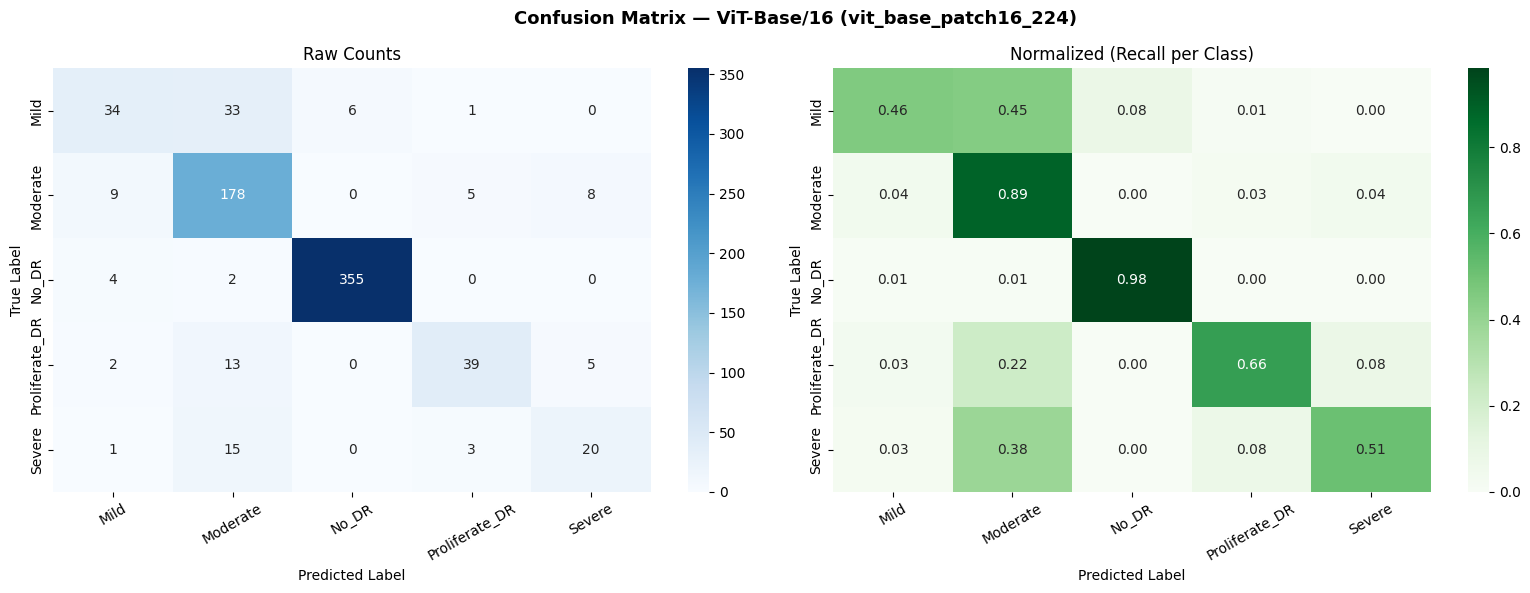

Saved: /kaggle/working/outputs/confusion_matrix.png


In [14]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ViT-Base/16 (vit_base_patch16_224)',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Normalized (Recall per Class)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/confusion_matrix.png")


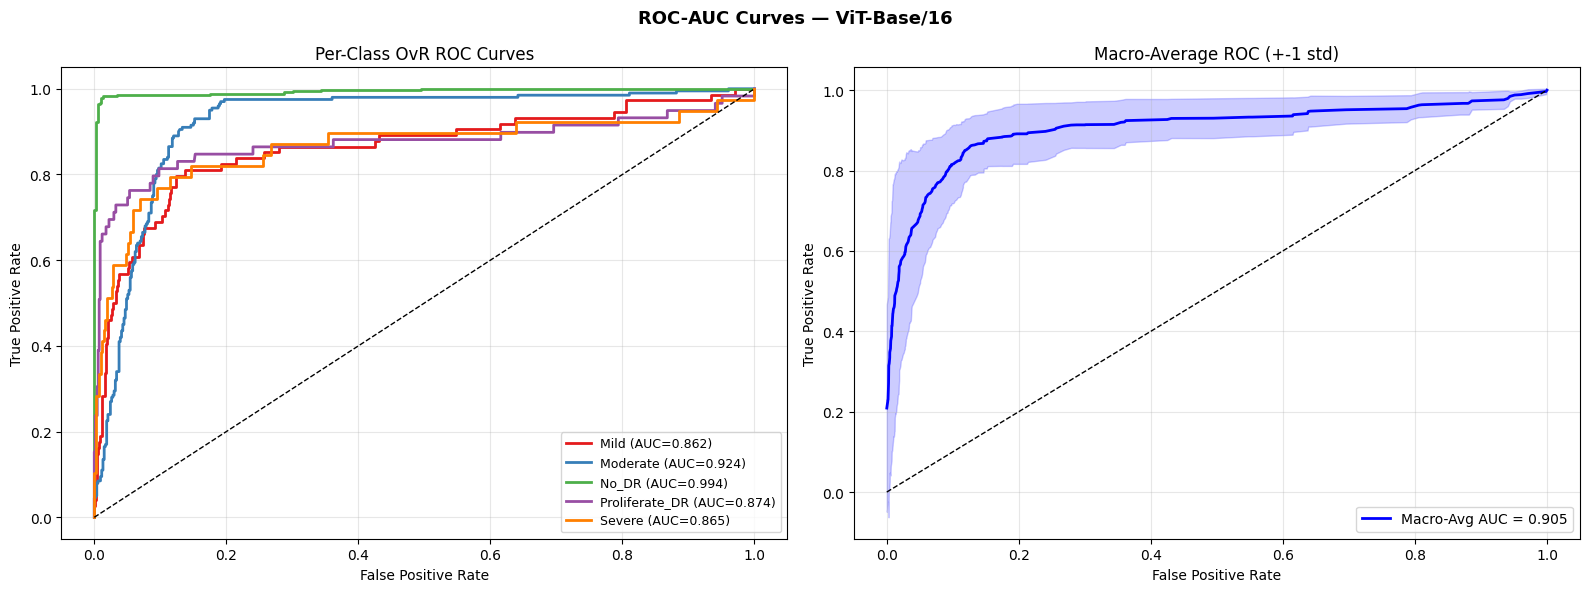

Saved : /kaggle/working/outputs/roc_auc.png
Macro-average AUC : 0.9055
  Mild                : AUC = 0.8620
  Moderate            : AUC = 0.9245
  No_DR               : AUC = 0.9945
  Proliferate_DR      : AUC = 0.8744
  Severe              : AUC = 0.8651


In [15]:
# ── ROC-AUC Curves ─────────────────────────────────────────────────────────
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC-AUC Curves — ViT-Base/16', fontsize=13, fontweight='bold')

for i in range(NUM_CLASSES):
    axes[0].plot(fpr[i], tpr[i], color=COLORS[i], lw=2,
                 label=f'{CLASS_NAMES[i]} (AUC={roc_auc[i]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Per-Class OvR ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

tpr_arr = np.array([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(NUM_CLASSES)])
tpr_std = tpr_arr.std(axis=0)
axes[1].plot(all_fpr, mean_tpr, 'b-', lw=2,
             label=f'Macro-Avg AUC = {macro_auc:.3f}')
axes[1].fill_between(all_fpr, mean_tpr - tpr_std, mean_tpr + tpr_std,
                     alpha=0.2, color='blue')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Macro-Average ROC (+-1 std)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved : {OUTPUT_DIR}/roc_auc.png")
print(f"Macro-average AUC : {macro_auc:.4f}")
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:20s}: AUC = {roc_auc[i]:.4f}")


In [16]:
# ── Classification Report ──────────────────────────────────────────────────
print("=" * 70)
print("  CLASSIFICATION REPORT — ViT-Base/16 (vit_base_patch16_224)")
print("=" * 70)
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))
print(f"Overall Validation Accuracy : {val_acc:.2f}%")
print("=" * 70)


  CLASSIFICATION REPORT — ViT-Base/16 (vit_base_patch16_224)
                precision    recall  f1-score   support

          Mild     0.6800    0.4595    0.5484        74
      Moderate     0.7386    0.8900    0.8073       200
         No_DR     0.9834    0.9834    0.9834       361
Proliferate_DR     0.8125    0.6610    0.7290        59
        Severe     0.6061    0.5128    0.5556        39

      accuracy                         0.8540       733
     macro avg     0.7641    0.7013    0.7247       733
  weighted avg     0.8521    0.8540    0.8482       733

Overall Validation Accuracy : 85.40%


## GradCAM++ Explainability

**Method:** GradCAM++ on the last Vision Transformer block's LayerNorm (`model.backbone.blocks[-1].norm1`).

**ViT Reshape Transform:** ViT produces `(B, 197, 768)` — 1 CLS token + 196 patch tokens.
The CLS token is removed (`tensor[:, 1:, :]`) and the remaining 196 tokens are reshaped to
a **14×14 spatial activation map** for the heatmap overlay.

**Output files:**
- `outputs/gradcam/correct/cam_NNN_tX_pY.png` — correctly classified images with heatmap
- `outputs/gradcam/wrong/cam_NNN_tX_pY.png` — misclassified images with heatmap
- `outputs/gradcam/correct/gradcam_grid.png` — 10-image summary grid (correct)
- `outputs/gradcam/wrong/gradcam_grid.png` — 10-image summary grid (wrong)


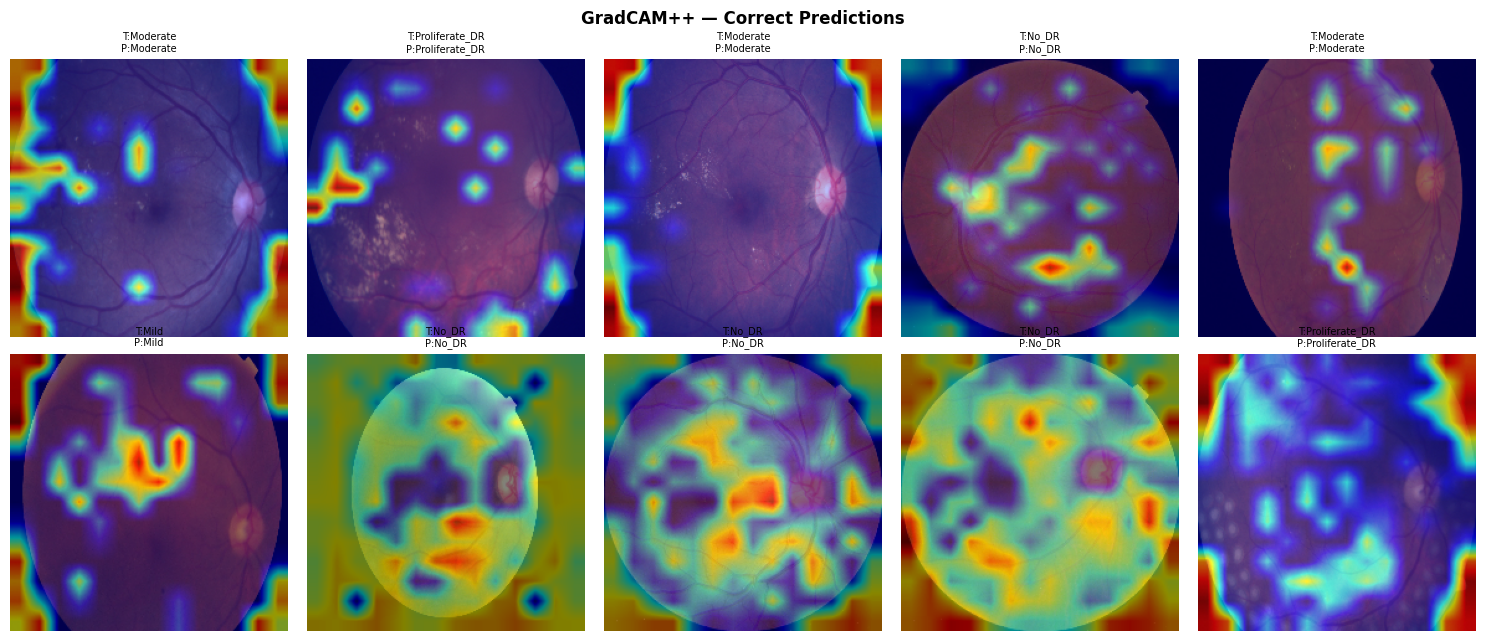

Saved 10 GradCAM images + grid -> /kaggle/working/outputs/gradcam/correct/


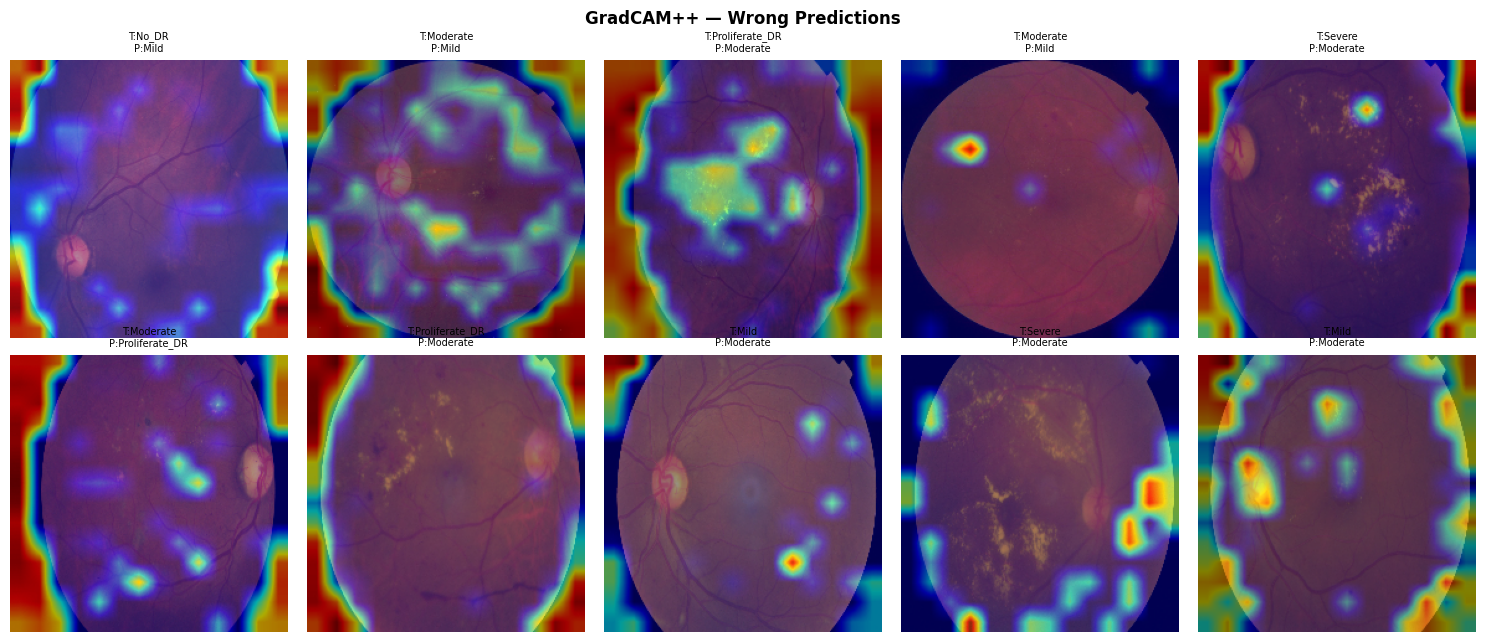

Saved 10 GradCAM images + grid -> /kaggle/working/outputs/gradcam/wrong/


In [17]:
# ── GradCAM++ Explainability ───────────────────────────────────────────────
def vit_reshape_transform(tensor, height=14, width=14):
    # tensor: (B, 197, 768) — 1 CLS token + 196 patch tokens
    result = tensor[:, 1:, :]   # remove CLS token -> (B, 196, 768)
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)   # -> (B, 768, 14, 14)

target_layers = [model.backbone.blocks[-1].norm1]
cam_obj = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers,
    reshape_transform=vit_reshape_transform
)

def denorm(tensor, mean=np.array([0.485, 0.456, 0.406]),
                   std=np.array([0.229, 0.224, 0.225])):
    t = tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip(t * std + mean, 0, 1)

# Collect correct and wrong prediction samples
model.eval()
correct_samples, wrong_samples = [], []
needed = 10
val_loader_single = DataLoader(val_set, batch_size=1, shuffle=True, num_workers=0)

for img, label in val_loader_single:
    if len(correct_samples) >= needed and len(wrong_samples) >= needed:
        break
    img_d = img.to(DEVICE)
    with torch.no_grad():
        pred = model(img_d).argmax(1).item()
    lbl = label.item()
    entry = (img, lbl, pred)
    if pred == lbl and len(correct_samples) < needed:
        correct_samples.append(entry)
    elif pred != lbl and len(wrong_samples) < needed:
        wrong_samples.append(entry)

def save_gradcam(samples, folder, label=''):
    grid_imgs = []
    for idx, (img, true_lbl, pred_lbl) in enumerate(samples):
        img_d = img.to(DEVICE)
        targets = [ClassifierOutputTarget(pred_lbl)]
        grayscale_cam = cam_obj(input_tensor=img_d, targets=targets)[0]
        rgb_img = denorm(img[0])
        cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        fname = f'{folder}/cam_{idx:03d}_t{true_lbl}_p{pred_lbl}.png'
        plt.imsave(fname, cam_img)
        grid_imgs.append((cam_img, true_lbl, pred_lbl))

    n    = min(len(grid_imgs), 10)
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3 + 0.5))
    fig.suptitle(f'GradCAM++ — {label} Predictions', fontsize=12,
                 fontweight='bold')
    axes = np.array(axes).flatten()
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(grid_imgs[i][0])
            t, p = grid_imgs[i][1], grid_imgs[i][2]
            axes[i].set_title(
                f'T:{CLASS_NAMES[t]}\nP:{CLASS_NAMES[p]}', fontsize=7)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'{folder}/gradcam_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved {n} GradCAM images + grid -> {folder}/")

save_gradcam(correct_samples, f'{OUTPUT_DIR}/gradcam/correct', label='Correct')
save_gradcam(wrong_samples,   f'{OUTPUT_DIR}/gradcam/wrong',   label='Wrong')


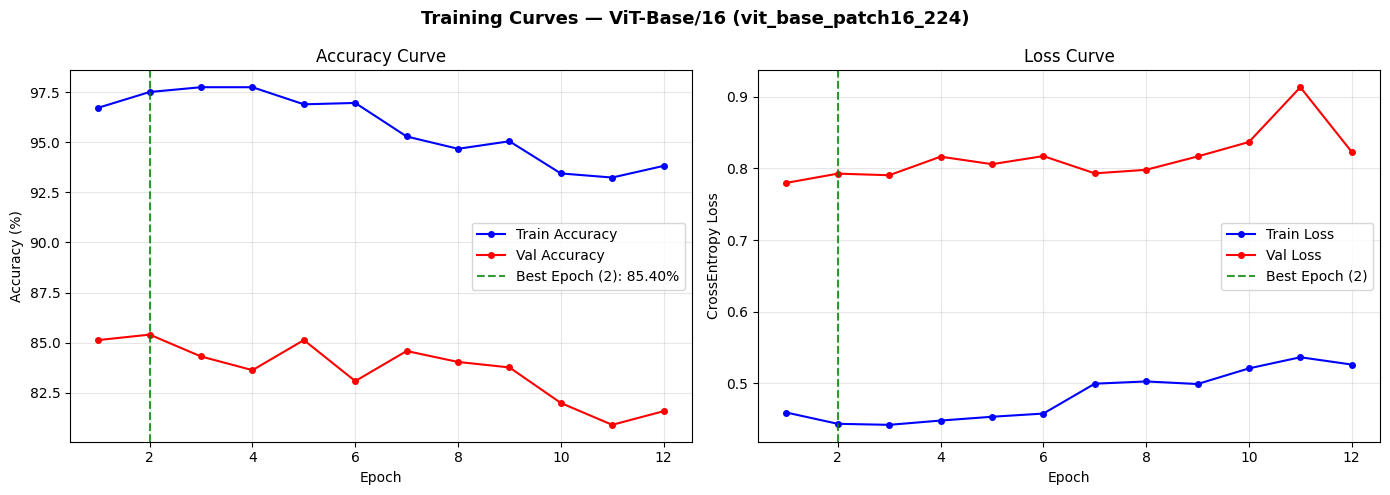

Saved: /kaggle/working/outputs/training_curves.png


In [18]:
# ── Training Curves ────────────────────────────────────────────────────────
epochs_ran = list(range(1, len(history['train_acc']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — ViT-Base/16 (vit_base_patch16_224)',
             fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(epochs_ran, history['train_acc'], 'b-o', ms=4, label='Train Accuracy')
axes[0].plot(epochs_ran, history['val_acc'],   'r-o', ms=4, label='Val Accuracy')
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8,
                label=f'Best Epoch ({best_epoch}): {best_val_acc:.2f}%')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_ran, history['train_loss'], 'b-o', ms=4, label='Train Loss')
axes[1].plot(epochs_ran, history['val_loss'],   'r-o', ms=4, label='Val Loss')
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8,
                label=f'Best Epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CrossEntropy Loss')
axes[1].set_title('Loss Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/training_curves.png")


## Strengths of the Proposed System

### Technical Strengths

1. **Global Self-Attention from Layer 1**
   Unlike CNNs that build local-to-global features hierarchically, ViT's self-attention operates
   globally on all 196 patches simultaneously. This enables direct modeling of long-range spatial
   relationships between lesions in different retinal quadrants — critical for Severe/Proliferative
   DR where pathology is spatially distributed.

2. **Patch-Level Tokenization**
   Dividing the 224×224 fundus image into 196 non-overlapping 16×16 patches preserves fine-grained
   spatial detail. Each patch is independently projected to a 768-dimensional embedding, retaining
   information about local textures, microaneurysm patterns, and hemorrhage morphology.

3. **Learnable Positional Embeddings**
   1D positional encodings capture the spatial structure of the 14×14 patch grid, allowing the model
   to distinguish foveal (central) lesion patterns from peripheral lesion distributions.

4. **Strong ImageNet-21K Transfer Learning**
   86M parameters pretrained on ImageNet-21K (14M images, 21K classes) provide exceptionally rich
   feature priors for texture recognition, edge detection, and morphological classification —
   directly transferable to retinal pathology recognition.

5. **CLS Token for Classification**
   The dedicated CLS token aggregates global image context by attending to all 196 patch tokens
   across 12 transformer blocks, producing a comprehensive 768-dimensional representation.

6. **Label Smoothing**
   Particularly beneficial for DR grading where grade boundaries (Grades 1–2 and 3–4) are
   clinically ambiguous and inter-grader variability reaches ~20%.

7. **Gradient Clipping (max_norm=1.0)**
   Prevents large gradient norms in attention layers from causing training instability.

### Medical Relevance

1. **Standard Severity Scale Alignment**
   The 5-class output maps directly to the International Clinical DR Severity Scale (ICDRSS),
   enabling direct clinical interpretation.

2. **GradCAM++ Pathology Localization**
   Explainability maps reveal diagnostically relevant attention regions:
   - Grade 1: Focused attention near fovea (microaneurysms)
   - Grade 2: Attention on hard exudate clusters and cotton-wool spots
   - Grade 3: Diffuse attention on hemorrhages and venous beading
   - Grade 4: Strong attention at optic disc (neovascularization)

3. **Referral Threshold Support**
   Model outputs P(Grade ≥ 3) which maps directly to urgent referral vs. routine follow-up
   clinical workflows, supporting triage automation in resource-limited settings.

4. **Calibrated Probability Outputs**
   Label smoothing improves probability calibration, making confidence scores more reliable
   for clinical decision support.

### Model Limitations

1. **Resolution Constraint (224×224)**
   Fine microaneurysms visible in high-resolution imaging (2048×2048) may be missed at 224×224.
   The 16×16 patch size coarsely divides the image, potentially losing sub-patch detail.

2. **Quadratic Attention Complexity**
   Standard ViT uses O(n²) self-attention over all tokens. At 224×224 this is manageable
   (197 tokens), but scaling to higher resolutions would be prohibitive.

3. **Single-Camera Distribution Bias**
   Trained on APTOS data; may degrade on images from different fundus camera manufacturers
   (Zeiss, Topcon, Canon) due to differing contrast profiles and color rendering.

4. **No Temporal/Longitudinal Modeling**
   Each image is classified independently — the model cannot leverage sequential fundus images
   to detect disease progression over time.

5. **Computational Requirements**
   ViT-Base requires ~4 GB VRAM for inference at batch_size=1; not suitable for real-time edge
   deployment without quantization or pruning.

6. **Data Balance vs. Clinical Prevalence**
   The balanced dataset (2000 per class) does not reflect real-world prevalence where
   No_DR >> Mild > Moderate > Severe > Proliferative. Models trained on balanced data may be
   overconfident on rarer grades in clinical deployment.


In [19]:
# ── Download / Save All Outputs ─────────────────────────────────────────────
import zipfile, shutil

ZIP_PATH = (
    '/kaggle/working/vit_outputs.zip' if ON_KAGGLE
    else '/content/vit_outputs.zip'
)
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, fnames in os.walk(OUTPUT_DIR):
        for fname in fnames:
            fpath   = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, os.path.dirname(OUTPUT_DIR))
            zf.write(fpath, arcname)
    for ckpt_file in ['vit_checkpoint.pth', 'vit_best_model.pth']:
        ckpt_path = os.path.join(
            '/kaggle/working' if ON_KAGGLE else '/content', ckpt_file
        )
        if os.path.exists(ckpt_path):
            zf.write(ckpt_path, ckpt_file)

print(f"ZIP created: {ZIP_PATH}")

if not ON_KAGGLE:
    from google.colab import files as colab_files
    colab_files.download(ZIP_PATH)
    print("Colab download initiated.")
else:
    print(f"On Kaggle: find ZIP in Output tab -> {ZIP_PATH}")


ZIP created: /kaggle/working/vit_outputs.zip
On Kaggle: find ZIP in Output tab -> /kaggle/working/vit_outputs.zip
